# ARIMA and Seasonal ARIMA
## Autoregressive Integrated Moving Averages
The general process for ARIMA models is the following:

- Visualize the Time Series Data
- Make the time series data stationary
- Plot the Correlation and AutoCorrelation Charts
- Construct the ARIMA Model or Seasonal ARIMA based on the data
- Use the model to make predictions

Let's go through these steps!

In [1312]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

In [1313]:
df=pd.read_csv('/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv')

In [1314]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
0,2019-12-31,72.482498,73.419998,72.379997,73.412498,71.520821,100805600,NaN,NaN,0.000000,NaN
1,2020-01-02,74.059998,75.150002,73.797501,75.087502,73.152649,135480400,2020-01-02,AAPL,0.376125,8.0
2,2020-01-03,74.287498,75.144997,74.125000,74.357498,72.441460,146322800,2020-01-03,AAPL,0.103833,6.0
3,2020-01-06,73.447502,74.989998,73.187500,74.949997,73.018677,118387200,2020-01-06,AAPL,0.779300,2.0
4,2020-01-07,74.959999,75.224998,74.370003,74.597504,72.675278,108872000,2020-01-07,AAPL,0.069367,3.0


In [1315]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,date,ticker,avg_sentiment,tweet_count
249,2020-12-24,131.320007,133.460007,131.100006,131.970001,129.679718,54930100,2020-12-24,AAPL,-0.128000,1.0
250,2020-12-28,133.990005,137.339996,133.509995,136.690002,134.317825,124486200,2020-12-28,AAPL,0.288850,2.0
251,2020-12-29,138.050003,138.789993,134.339996,134.869995,132.529404,121047300,2020-12-29,AAPL,0.000000,2.0
252,2020-12-30,135.580002,135.990005,133.399994,133.720001,131.399368,96452100,2020-12-30,AAPL,0.000000,1.0
253,2020-12-31,134.080002,134.740005,131.720001,132.690002,130.387222,99116600,2020-12-31,AAPL,0.076167,3.0


In [1316]:
## Cleaning up the data
df = df[["Date", "Close", "avg_sentiment"]]

df.head()

,Date,Close,avg_sentiment
0,2019-12-31,73.412498,0.000000
1,2020-01-02,75.087502,0.376125
2,2020-01-03,74.357498,0.103833
3,2020-01-06,74.949997,0.779300
4,2020-01-07,74.597504,0.069367


In [1317]:
# Convert Month into Datetime 
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

df.head()

,Close,avg_sentiment
Date,,
2019-12-31,73.412498,0.000000
2020-01-02,75.087502,0.376125
2020-01-03,74.357498,0.103833
2020-01-06,74.949997,0.779300
2020-01-07,74.597504,0.069367


In [1318]:
df.describe()

,Close,avg_sentiment
count,254.000000,254.000000
mean,95.260718,0.093034
std,21.810137,0.181274
min,56.092499,-0.421500
25%,77.379377,0.000000
50%,91.421249,0.070178
75%,115.739374,0.219082
max,136.690002,0.779300


Step 2: Visualize the Data

<Axes: xlabel='Date'>

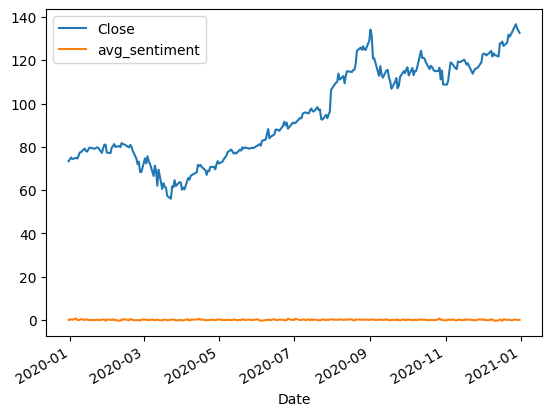

In [1319]:
df.plot()

In [1320]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [1321]:
test_result=adfuller(df['Close'])

In [1322]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(close_price):
    result=adfuller(close_price)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


In [1323]:
adfuller_test(df['Close'])

ADF Test Statistic : -0.12702885454878415
p-value : 0.9466789170863883
#Lags Used : 1
Number of Observations Used : 252
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


Differencing

In [1324]:
df['Close First Difference'] = df['Close'] - df['Close'].shift(1)

In [1325]:
df['Close'].shift(1)

Date
2019-12-31           NaN
2020-01-02     73.412498
2020-01-03     75.087502
2020-01-06     74.357498
2020-01-07     74.949997
                 ...    
2020-12-24    130.960007
2020-12-28    131.970001
2020-12-29    136.690002
2020-12-30    134.869995
2020-12-31    133.720001
Name: Close, Length: 254, dtype: float64

In [1326]:
df.head(14)

,Close,avg_sentiment,Close First Difference
Date,,,
2019-12-31,73.412498,0.000000,NaN
2020-01-02,75.087502,0.376125,1.675003
2020-01-03,74.357498,0.103833,-0.730003
2020-01-06,74.949997,0.779300,0.592499
2020-01-07,74.597504,0.069367,-0.352493
2020-01-08,75.797501,-0.062567,1.199997
2020-01-09,77.407501,0.153100,1.610001
2020-01-10,77.582497,0.426825,0.174995
2020-01-13,79.239998,0.026950,1.657501


In [1327]:
## Again test dickey fuller test
adfuller_test(df['Close First Difference'].dropna())

ADF Test Statistic : -18.972801652135207
p-value : 0.0
#Lags Used : 0
Number of Observations Used : 252
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<Axes: xlabel='Date'>

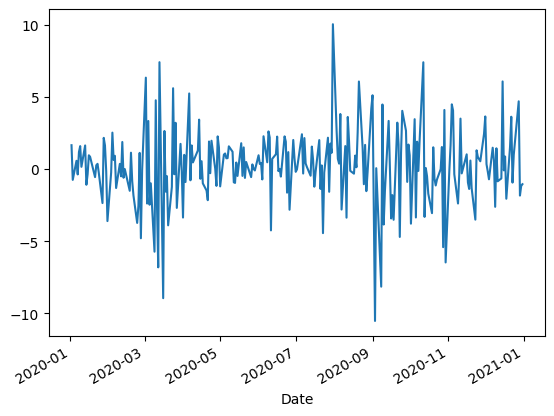

In [1328]:
df['Close First Difference'].plot()


Auto Regressive Model

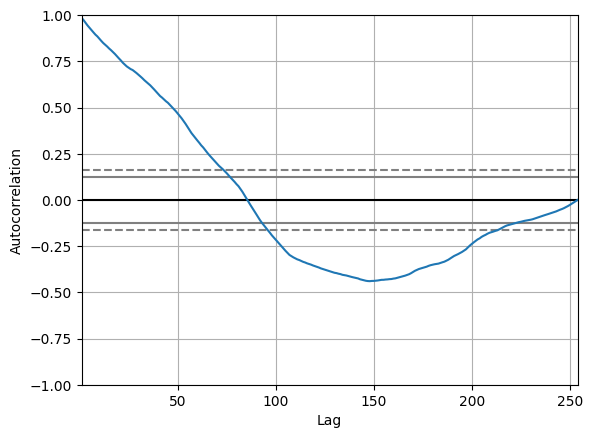

In [1329]:
from pandas.plotting import autocorrelation_plot, scatter_matrix
autocorrelation_plot(df['Close'])
plt.show()

Final Thoughts on Autocorrelation and Partial Autocorrelation

In [1330]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm

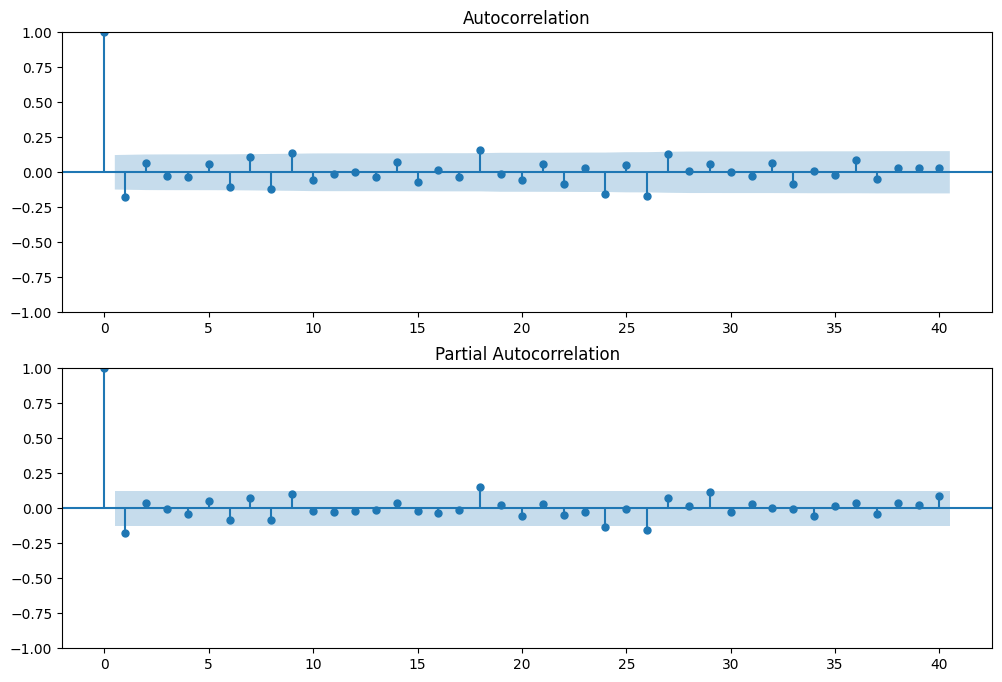

In [1331]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Close First Difference'].dropna(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Close First Difference'].dropna(),lags=40,ax=ax2)

In [1332]:
# For non-seasonal data
#p=1, d=1, q=0 or 1
from statsmodels.tsa.arima_model import ARIMA

In [1333]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

model=ARIMA(df['Close'],order=(1,1,1))
model_fit=model.fit()

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [1334]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                  254
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -597.411
Date:                Thu, 28 May 2026   AIC                           1200.821
Time:                        13:29:49   BIC                           1211.422
Sample:                             0   HQIC                          1205.086
                                - 254                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3787      0.264     -1.437      0.151      -0.895       0.138
ma.L1          0.2135      0.281      0.761      0.447      -0.336       0.763
sigma2         6.5837      0.389     16.904      0.000       5.820       7.347
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                81.22
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               1.40   Skew:                            -0.23
Prob(H) (two-sided):                  0.12   Kurtosis:                         5.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Date'>

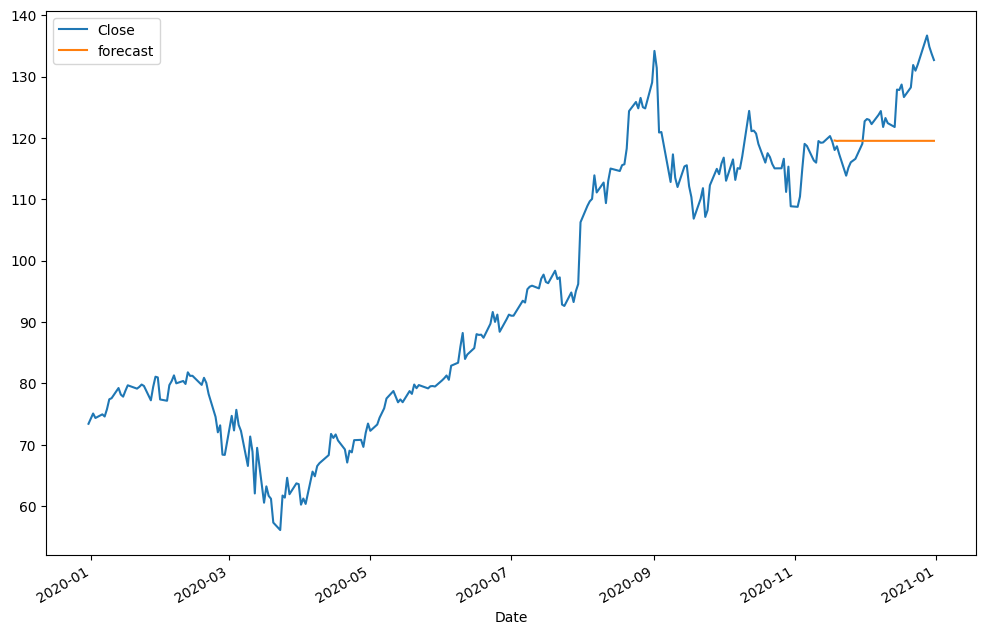

In [1335]:
df['forecast']=model_fit.predict(start=len(df)-30, end=len(df)-1, dynamic=True)
df[['Close','forecast']].plot(figsize=(12,8))

In [1336]:
import statsmodels.api as sm

In [1337]:
model=sm.tsa.statespace.SARIMAX(df['Close'],order=(1, 1, 1),seasonal_order=(1,1,1,12))
results=model.fit()

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [1338]:
df.shape

(254, 4)

<Axes: xlabel='Date'>

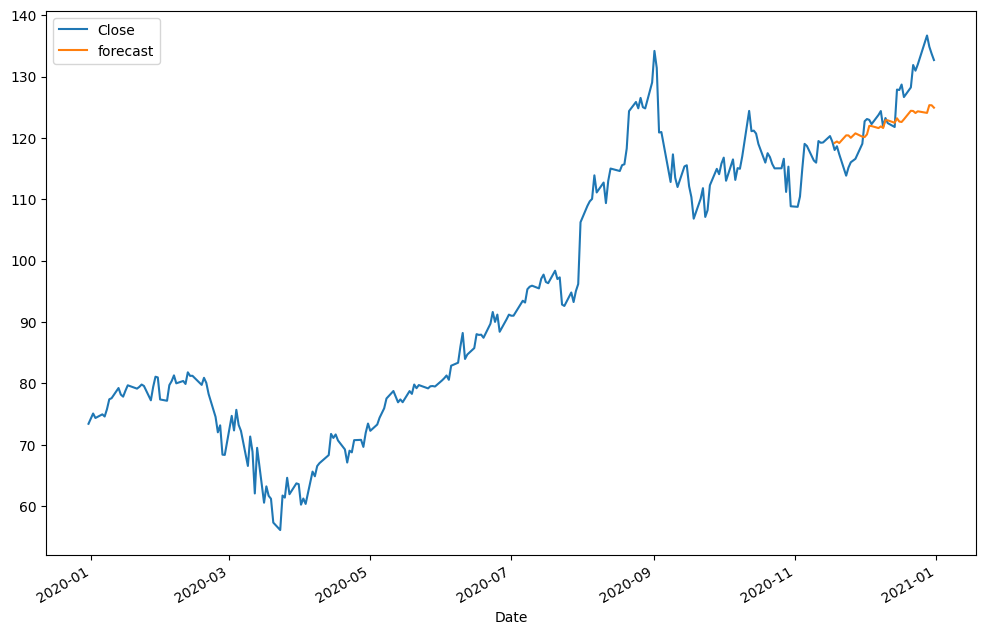

In [1339]:
df['forecast']=results.predict(start=len(df)-30, end=len(df)-1,dynamic=True)
df[['Close','forecast']].plot(figsize=(12,8))

In [1340]:
from pandas.tseries.offsets import BDay
future_dates=[df.index[-1]+ BDay(x) for x in [1,3,5]]

In [1341]:
future_dates

[Timestamp('2021-01-01 00:00:00'),
 Timestamp('2021-01-05 00:00:00'),
 Timestamp('2021-01-07 00:00:00')]

In [1342]:
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=df.columns)

In [1343]:
future_datest_df.tail()

,Close,avg_sentiment,Close First Difference,forecast
2021-01-05,NaN,NaN,NaN,NaN
2021-01-07,NaN,NaN,NaN,NaN


In [1344]:
future_df=pd.concat([df,future_datest_df])

<Axes: xlabel='Date'>

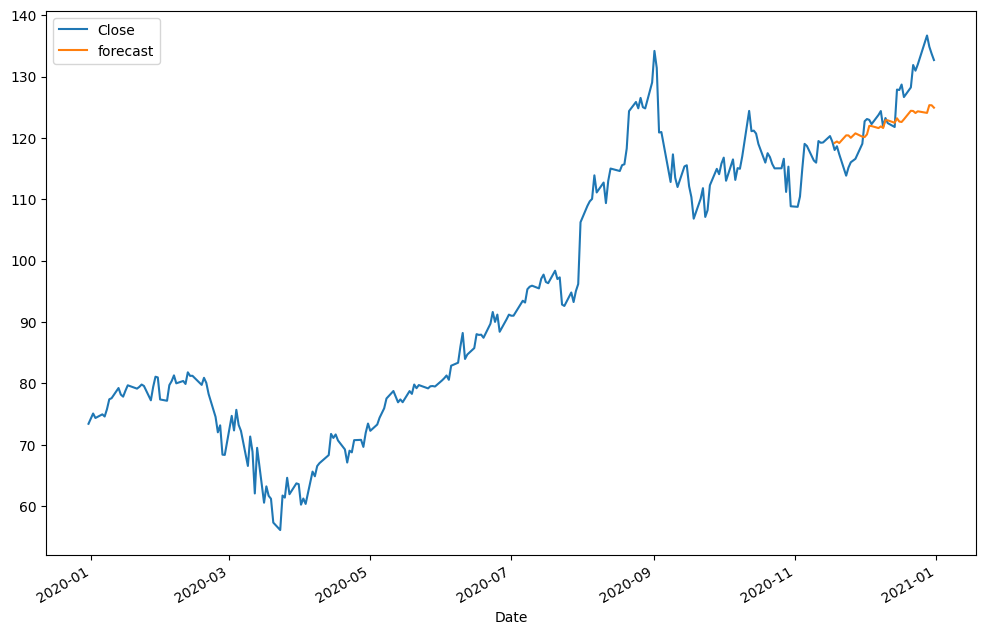

In [1345]:
future_df = df.copy()
future_df['forecast'] = results.predict(start=len(df)-30, end=len(df)-1, dynamic= True)
future_df[['Close', 'forecast']].plot(figsize=(12, 8))

# 5 Loop through companies

In [1346]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

In [1347]:
# Company files
company_files = {
    "AAPL": "/home/chakuunaa/BD_ADA_CA2sem2/data/aapl_features.csv",
    "MSFT": "/home/chakuunaa/BD_ADA_CA2sem2/data/msft_features.csv",
    "GOOG": "/home/chakuunaa/BD_ADA_CA2sem2/data/goog_features.csv",
    "TSLA": "/home/chakuunaa/BD_ADA_CA2sem2/data/tsla_features.csv",
    "AMZN": "/home/chakuunaa/BD_ADA_CA2sem2/data/amzn_features.csv"
}

# Empty list
results_list = []

In [1348]:
# Loop through companies
for company, path in company_files.items():

    # Read data
    df = pd.read_csv(path, parse_dates=['Date'])

    # Keep Close column only
    series = df['Close'].dropna()

    # Build ARIMA model
    model = ARIMA(series, order=(1,1,1))

    results = model.fit()

    # Forecast next 5 days
    forecast_values = results.forecast(steps=5)

    # Save results
    results_list.append({
        "Company": company,
        "1 Day Forecast": forecast_values.iloc[0],
        "3 Day Forecast": forecast_values.iloc[2],
        "5 Day Forecast": forecast_values.iloc[4]
    })

# Final table
forecast_table = pd.DataFrame(results_list)

forecast_table

/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/chakuunaa/anaconda3/envs/spark311/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

,Company,1 Day Forecast,3 Day Forecast,5 Day Forecast
0,AAPL,132.840450,132.805051,132.799973
1,MSFT,222.120321,222.192292,222.203854
2,GOOG,87.422214,87.463118,87.469369
3,TSLA,235.178537,235.186210,235.186579
4,AMZN,162.923288,162.905905,162.898476


In [1349]:
forecast_table.to_csv(
    "/home/chakuunaa/BD_ADA_CA2sem2/data/all_company_forecasts.csv",
    index=False
)